C:\Users\loren\AppData\Local\Temp\ipykernel_12396\1733386494.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", progress=False)


Treinando o modelo com Log-Returns...
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 0.0203 - val_loss: 0.0082
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0068 - val_loss: 0.0063
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0061 - val_loss: 0.0052
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0059 - val_loss: 0.0048
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0056 - val_loss: 0.0051
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0055 - val_loss: 0.0053
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0054 - val_loss: 0.0047
Epoch 9/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0052 - val_loss: 0.0053
Epoch 10/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0053 - val_loss: 0.0048
Epoch 11/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0052 - val_loss: 0.0056
Epoch 12/50
68/68 ━━━━━━━

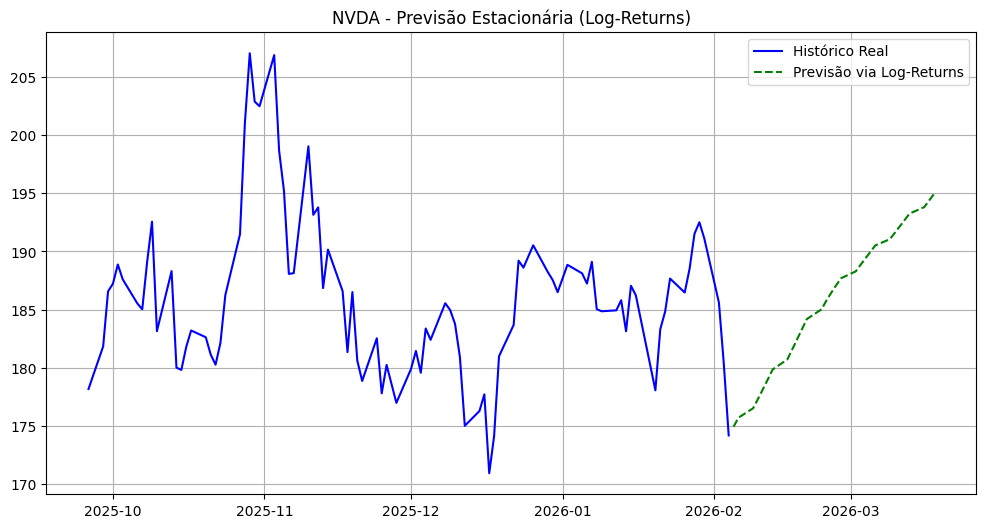

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

ticker = "NVDA"
data = yf.download(ticker, start="2015-01-01", progress=False)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
data.columns = data.columns.astype(str)

data = data[['Close', 'Volume']].copy()

def add_indicators(df):
    df = df.copy()
    # Log_Return agora é nossa estrela principal
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    df['MA7'] = df['Close'].rolling(window=7).mean()
    df['MA21'] = df['Close'].rolling(window=21).mean()
    df['Volatility'] = df['Log_Return'].rolling(window=7).std()
    
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df['RSI'] = 100 - (100 / (1 + (gain/loss)))
    return df

data = add_indicators(data)
data.dropna(inplace=True)

# 2. SPLIT E NORMALIZAÇÃO
split = int(len(data) * 0.8)
train_df, test_df = data.iloc[:split], data.iloc[split:]

scaler = MinMaxScaler()
scaler.fit(train_df)

train_scaled = scaler.transform(train_df)
test_scaled = scaler.transform(test_df)

# 3. SEQUÊNCIAS (Alvo: Log_Return)
# Descobrimos qual é a posição da coluna Log_Return
target_col_idx = data.columns.get_loc('Log_Return')

def create_sequences(dataset, seq_len, target_idx):
    X, y = [], []
    for i in range(seq_len, len(dataset)):
        X.append(dataset[i-seq_len:i])
        y.append(dataset[i, target_idx]) # O modelo agora aprende o RETORNO
    return np.array(X), np.array(y)

seq_len = 60
X_train, y_train = create_sequences(train_scaled, seq_len, target_col_idx)
X_test, y_test = create_sequences(test_scaled, seq_len, target_col_idx)

# 4. MODELO LSTM
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=True), # Reduzi um pouco os neurônios para evitar decoreba
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1) # Previsão do log-return do dia t+1
])

model.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Treinando o modelo com Log-Returns...")
model.fit(X_train, y_train, validation_data=(X_test, y_test), 
          epochs=50, batch_size=32, callbacks=[early_stop], verbose=1)

# 5. PREVISÃO RECURSIVA
future_days = 30
buffer_df = data.iloc[-100:].copy() 
predicted_prices = []

current_sequence_scaled = test_scaled[-seq_len:]

for i in range(future_days):
    input_reshaped = current_sequence_scaled.reshape(1, seq_len, X_train.shape[2])
    
    # Prevemos o LOG-RETURN (scaled)
    pred_log_return_scaled = model.predict(input_reshaped, verbose=0)[0, 0]
    
    # Desnormalizamos para ter o log-return real
    dummy = np.zeros((1, len(data.columns)))
    dummy[0, target_col_idx] = pred_log_return_scaled
    pred_log_return = scaler.inverse_transform(dummy)[0, target_col_idx]
    
    # CALCULAMOS O PREÇO: P(t+1) = P(t) * exp(r)
    last_price = buffer_df['Close'].iloc[-1]
    pred_price = last_price * np.exp(pred_log_return)
    predicted_prices.append(pred_price)
    
    # Atualizar buffer para o próximo dia
    new_date = buffer_df.index[-1] + pd.Timedelta(days=1)
    new_row = pd.DataFrame({
        'Close': [pred_price],
        'Volume': [buffer_df['Volume'].mean()],
        'Log_Return': [pred_log_return], # Usamos o retorno que acabamos de prever
        'MA7': [0.0], 'MA21': [0.0], 'Volatility': [0.0], 'RSI': [0.0]
    }, index=[new_date])
    
    buffer_df = pd.concat([buffer_df, new_row])
    buffer_df = add_indicators(buffer_df) 
    
    # Prepara a sequência escalada para a próxima iteração
    current_sequence_scaled = scaler.transform(buffer_df.iloc[-seq_len:])

# 6. PLOTAGEM
plt.figure(figsize=(12,6))
plt.plot(data.index[-90:], data['Close'].iloc[-90:], label="Histórico Real", color='blue')
future_dates = pd.date_range(data.index[-1], periods=future_days + 1, freq='B')[1:]
plt.plot(future_dates, predicted_prices, label="Previsão via Log-Returns", color='green', linestyle='--')
plt.title(f"NVDA - Previsão Estacionária (Log-Returns)")
plt.legend()
plt.grid(True)
plt.show()